In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
import seaborn as sns

In [3]:
df=pd.read_csv("water_potability.csv")
print(df.head())

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


In [4]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
print(df.isnull())

         ph  Hardness  Solids  Chloramines  Sulfate  Conductivity  \
0      True     False   False        False    False         False   
1     False     False   False        False     True         False   
2     False     False   False        False     True         False   
3     False     False   False        False    False         False   
4     False     False   False        False    False         False   
...     ...       ...     ...          ...      ...           ...   
3271  False     False   False        False    False         False   
3272  False     False   False        False     True         False   
3273  False     False   False        False     True         False   
3274  False     False   False        False     True         False   
3275  False     False   False        False     True         False   

      Organic_carbon  Trihalomethanes  Turbidity  Potability  
0              False            False      False       False  
1              False            False      Fa

In [7]:
print(df.isnull().sum())

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [8]:
df['ph']=df['ph'].fillna(df['ph'].mean())
df['Sulfate']=df['Sulfate'].fillna(df['Sulfate'].mean())
df['Trihalomethanes']=df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean())
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [9]:
df.isnull().sum()


ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

<Axes: >

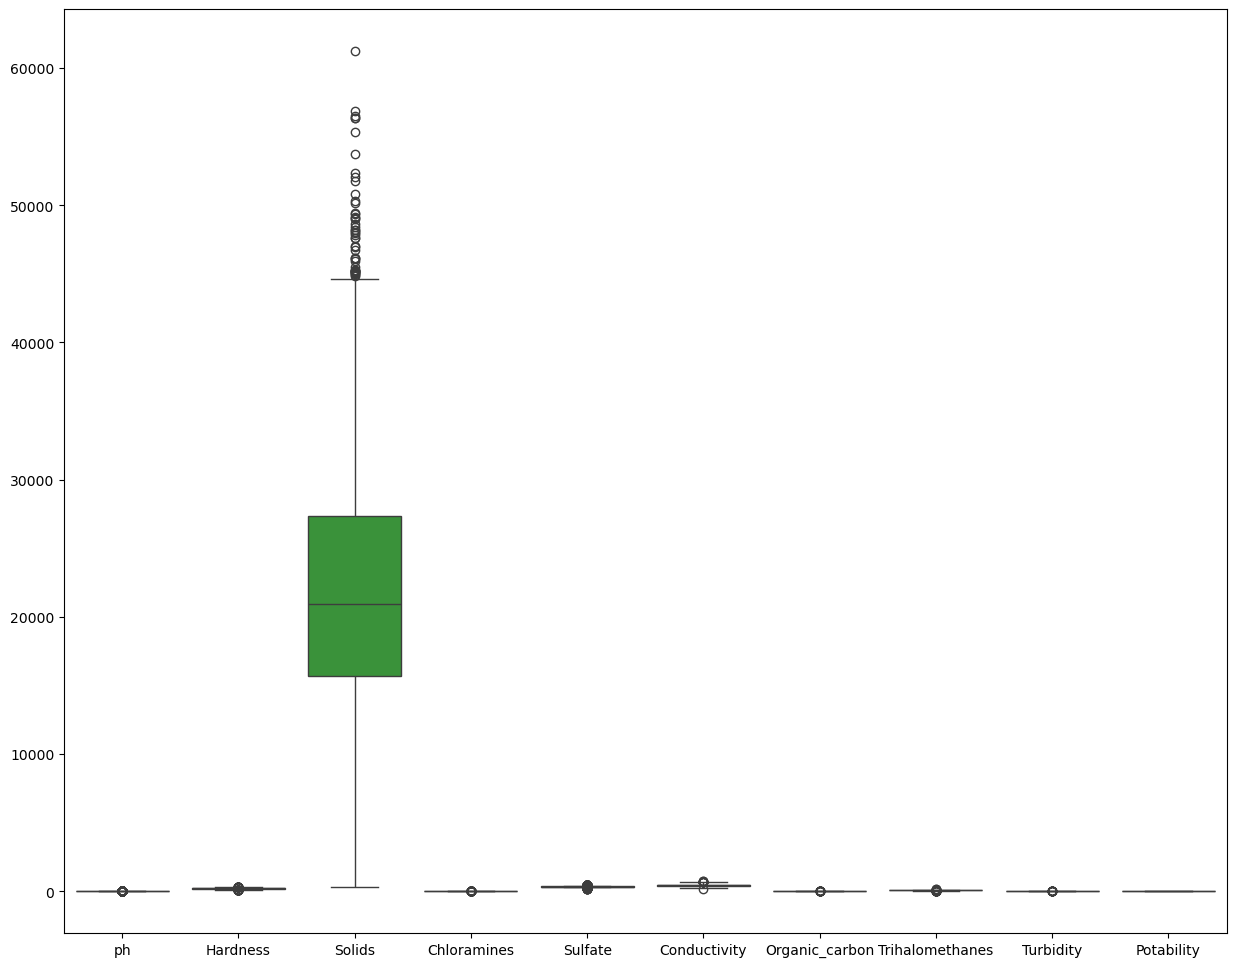

In [10]:
import seaborn as sns
plt.figure(figsize=(15,12))
sns.boxplot(df)

In [11]:
def iqr_det(df):
    outlier_list=[]
    df=sorted(df)
    q1=np.percentile(df,25)
    q3=np.percentile(df,75)
    IQR= q3-q1
    lwr_bound=q1-(1.5*IQR)
    upr_bound=q3+(1.5*IQR)
    
    for i in df:
        if(i<lwr_bound or i>upr_bound):
            outlier_list.append(i)
    return outlier_list

for i in ['ph','Hardness','Solids','Chloramines','Sulfate','Conductivity','Organic_carbon','Trihalomethanes','Turbidity','Potability']:
    outliers=iqr_det(df[i])
    print("Outliers in ",i,"attribute:",outliers)


Outliers in  ph attribute: [0.0, 0.2274990502021987, 0.975577989772022, 0.9899122128791388, 1.4317815547427415, 1.757037115490783, 1.844538366498842, 1.985383359263048, 2.1285314339651724, 2.376768075959951, 2.538115773481364, 2.5581027992200664, 2.5692435620279186, 2.612035914817261, 2.690831240408815, 2.798549098862777, 2.803563057437167, 2.9251743203391, 2.9454690611226875, 2.974429410478532, 3.1020755653395566, 3.14871228517616, 3.2309731059187423, 3.2616697873910208, 3.2728200975185464, 3.3376289979634506, 3.3445885334830234, 3.388090610523891, 3.41035967073924, 3.4223941642163864, 3.4264503676355647, 3.433874059145088, 3.434855759978651, 3.4450618643852127, 3.514545528745279, 3.551579176967154, 3.5908223640059966, 3.623165848258656, 3.629922064880713, 3.633162828862528, 3.637170625355805, 3.641629777473381, 3.657123132566738, 3.664710561719395, 3.6768449933847727, 3.678431807207628, 3.681076270548827, 3.6919326929347136, 3.715171359884693, 3.71608007538699, 3.717703934990307, 3.7

In [12]:
import numpy as np
import pandas as pd

def handle_outliers(data):
    tenth_percentile = np.percentile(data, 10)
    ninetieth_percentile = np.percentile(data, 90)

    print('10th percentile:', tenth_percentile)
    print('90th percentile:', ninetieth_percentile)

    # Flooring and Capping
    capped_data = np.where(data < tenth_percentile, tenth_percentile, data)
    capped_data = np.where(capped_data > ninetieth_percentile, ninetieth_percentile, capped_data)

    return capped_data

# Apply flooring and capping for specified columns

for i in ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 
          'Conductivity', 'Organic_carbon', 'Trihalomethanes', 
          'Turbidity', 'Potability']:
    
    df[i] = handle_outliers(df[i])
    print(df[i])


10th percentile: 5.282194491912188
90th percentile: 8.925046875415749
0       7.080795
1       5.282194
2       8.099124
3       8.316766
4       8.925047
          ...   
3271    5.282194
3272    7.808856
3273    8.925047
3274    5.282194
3275    7.874671
Name: ph, Length: 3276, dtype: float64
10th percentile: 155.2239641077801
90th percentile: 236.35070740017414
0       204.890455
1       155.223964
2       224.236259
3       214.373394
4       181.101509
           ...    
3271    193.681735
3272    193.553212
3273    175.762646
3274    230.603758
3275    195.102299
Name: Hardness, Length: 3276, dtype: float64
10th percentile: 11740.528189473214
90th percentile: 33814.93523020222
0       20791.318981
1       18630.057858
2       19909.541732
3       22018.417441
4       17978.986339
            ...     
3271    33814.935230
3272    17329.802160
3273    33155.578218
3274    11983.869376
3275    17404.177061
Name: Solids, Length: 3276, dtype: float64
10th percentile: 5.181270677724534

<Axes: >

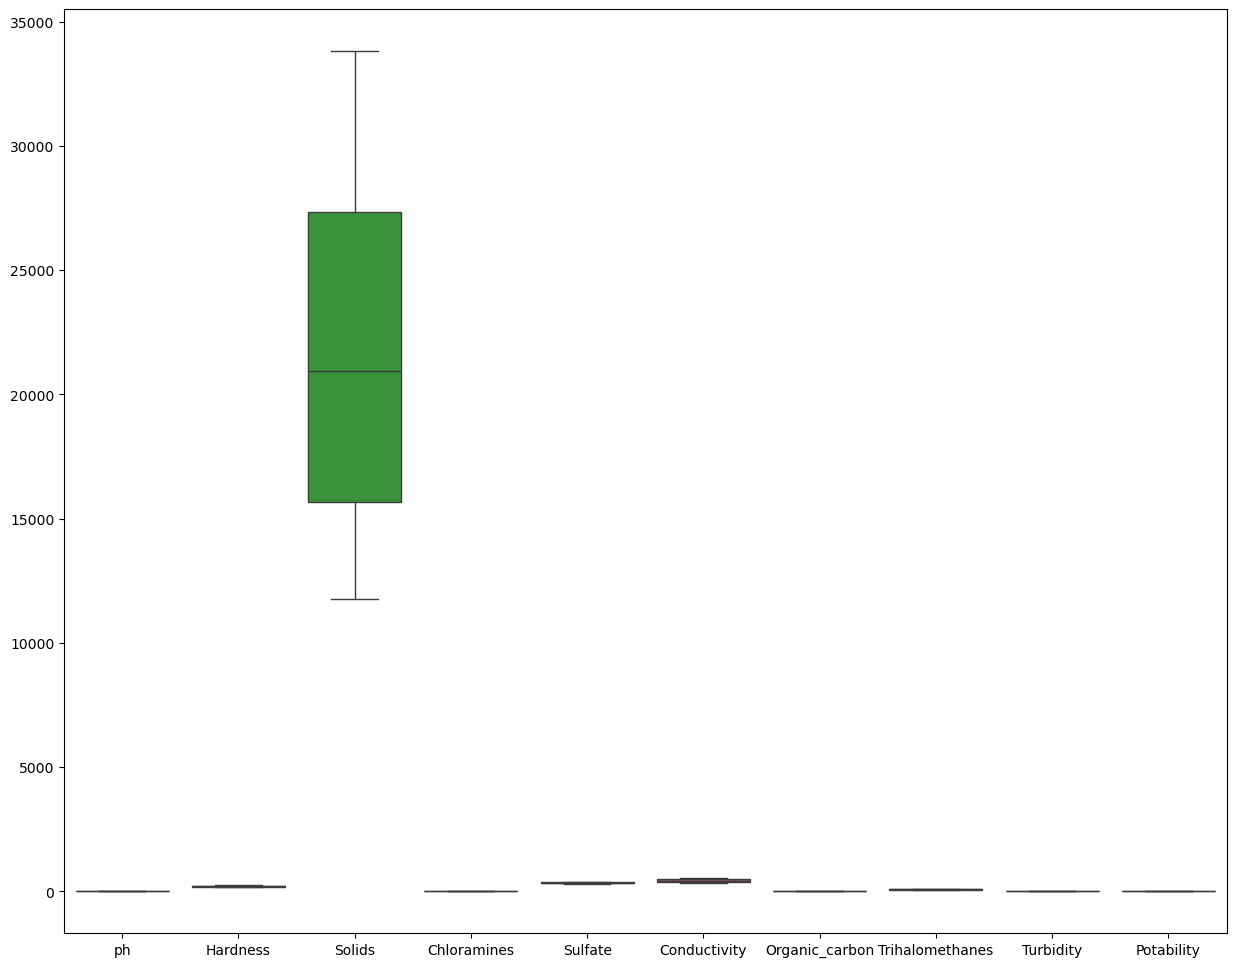

In [13]:
import seaborn as sns
plt.figure(figsize=(15,12))
sns.boxplot(df)

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   float64
dtypes: float64(10)
memory usage: 256.1 KB
None


In [15]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,533.297241,10.379783,85.900095,2.963135,0.0
1,5.282194,155.223964,18630.057858,6.635246,333.775777,533.297241,15.180013,56.329076,4.500656,0.0
2,8.099124,224.236259,19909.541732,9.122578,333.775777,418.606213,16.868637,66.420093,3.055934,0.0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,85.900095,4.628771,0.0
4,8.925047,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,46.209473,4.075075,0.0


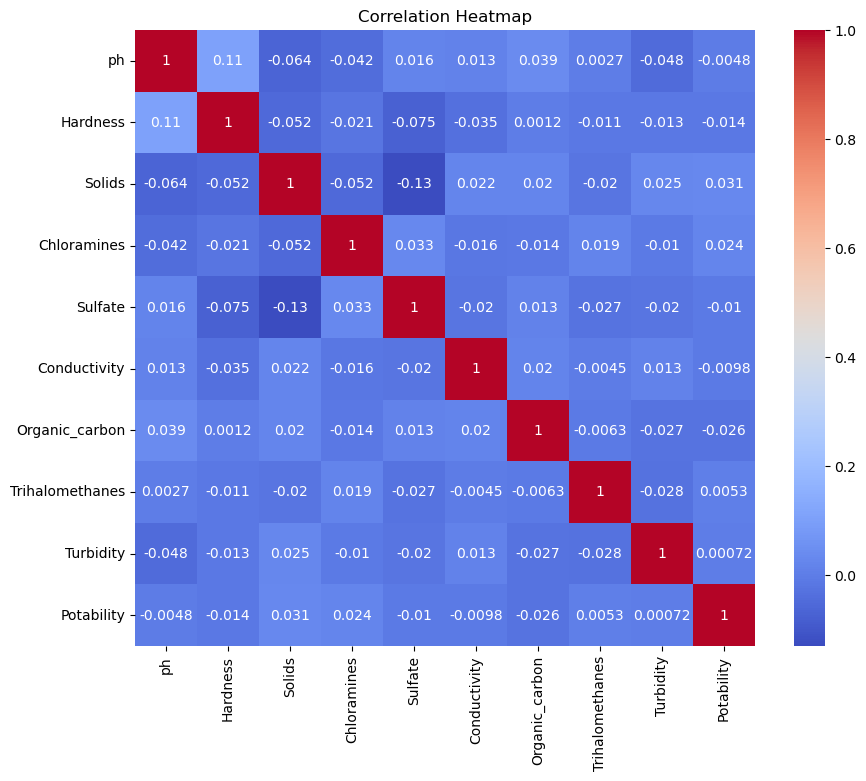

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [17]:
df.corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.105065,-0.064434,-0.041576,0.016276,0.012899,0.038656,0.002678,-0.047835,-0.004821
Hardness,0.105065,1.000000,-0.052196,-0.021179,-0.074932,-0.034727,0.001227,-0.010852,-0.012726,-0.013517
Solids,-0.064434,-0.052196,1.000000,-0.052349,-0.129632,0.022499,0.020475,-0.020326,0.025318,0.030550
Chloramines,-0.041576,-0.021179,-0.052349,1.000000,0.032867,-0.016131,-0.013517,0.019006,-0.010339,0.023827
Sulfate,0.016276,-0.074932,-0.129632,0.032867,1.000000,-0.019721,0.012888,-0.026936,-0.019855,-0.010171
Conductivity,0.012899,-0.034727,0.022499,-0.016131,-0.019721,1.000000,0.020237,-0.004521,0.013230,-0.009792
Organic_carbon,0.038656,0.001227,0.020475,-0.013517,0.012888,0.020237,1.000000,-0.006313,-0.026846,-0.026049
Trihalomethanes,0.002678,-0.010852,-0.020326,0.019006,-0.026936,-0.004521,-0.006313,1.000000,-0.028199,0.005333
Turbidity,-0.047835,-0.012726,0.025318,-0.010339,-0.019855,0.013230,-0.026846,-0.028199,1.000000,0.000716
Potability,-0.004821,-0.013517,0.030550,0.023827,-0.010171,-0.009792,-0.026049,0.005333,0.000716,1.000000


In [18]:
df.corr()>0.5

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,True,False,False,False,False,False,False,False,False,False
Hardness,False,True,False,False,False,False,False,False,False,False
Solids,False,False,True,False,False,False,False,False,False,False
Chloramines,False,False,False,True,False,False,False,False,False,False
Sulfate,False,False,False,False,True,False,False,False,False,False
Conductivity,False,False,False,False,False,True,False,False,False,False
Organic_carbon,False,False,False,False,False,False,True,False,False,False
Trihalomethanes,False,False,False,False,False,False,False,True,False,False
Turbidity,False,False,False,False,False,False,False,False,True,False
Potability,False,False,False,False,False,False,False,False,False,True


In [19]:
from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()
df[['ph','Hardness','Solids','Chloramines','Sulfate','Conductivity',
    'Organic_carbon','Trihalomethanes','Turbidity','Potability']] = scale.fit_transform(
    df[['ph','Hardness','Solids','Chloramines','Sulfate','Conductivity',
        'Organic_carbon','Trihalomethanes','Turbidity','Potability']]
)

df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,0.493734,0.612209,0.410013,0.537624,0.887339,1.000000,0.030548,1.000000,0.005595,0.0
1,0.000000,0.000000,0.312105,0.368907,0.494448,1.000000,0.603313,0.254962,0.764738,0.0
2,0.773276,0.850673,0.370067,1.000000,0.494448,0.449078,0.804800,0.509204,0.051414,0.0
3,0.833021,0.729099,0.465602,0.730230,0.755809,0.183252,0.991881,1.000000,0.827994,0.0
4,1.000000,0.318977,0.282610,0.346415,0.227098,0.352069,0.171167,0.000000,0.554610,0.0


In [20]:
X=df.drop('Potability',axis=1)
y=df['Potability']

In [21]:
from sklearn.model_selection import train_test_split


# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)


In [22]:
from sklearn.linear_model import LogisticRegression
model_lg=LogisticRegression()

model_lg.fit(X_train,y_train)
model_lg.predict(X_test)



array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [23]:
model_lg.score(X_test,y_test)

0.6276703967446592

In [24]:
#import pickle

#with open("mymodelfres.pkl","wb") as f:
 #   pickle.dump(model_lg,f)

In [25]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(max_depth=3)
model_dt.fit(X_train, y_train)
model_dt.predict(X_test)
model_dt.score(X_test,y_test)

0.6510681586978637

In [26]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=18)
model_knn.fit(X_train, y_train)
model_knn.predict(X_test)
model_knn.score(X_test,y_test)

0.6632756866734486

In [27]:
samples = [
    [7.2,204.8,18750,6.8,320.5,410.2,12.4,65.3,3.8],
    [6.5,180.1,22000,7.5,290.4,390.7,10.9,58.1,4.1],
    [8.1,230.4,15000,5.9,340.2,450.6,14.2,72.5,2.9]
]

model_knn.predict(samples)

D:\Ana\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0., 0., 0.])

In [33]:
import pandas as pd

sample = pd.DataFrame({
    'ph':[7.2],
    'Hardness':[204.8],
    'Solids':[18750],
    'Chloramines':[6.8],
    'Sulfate':[320.5],
    'Conductivity':[410.2],
    'Organic_carbon':[12.4],
    'Trihalomethanes':[65.3],
    'Turbidity':[3.8]
})

prediction = model_dt.predict(sample)

print(prediction)

[0.]


In [34]:


sample = pd.DataFrame({
    'ph':[7.1],
    'Hardness':[180],
    'Solids':[15000],
    'Chloramines':[6.5],
    'Sulfate':[300],
    'Conductivity':[400],
    'Organic_carbon':[14],
    'Trihalomethanes':[60],
    'Turbidity':[3]
})

prediction = model_dt.predict(sample)

print(prediction)

[0.]


In [35]:
import pandas as pd

sample = pd.DataFrame({
    'ph':[7.4],
    'Hardness':[165],
    'Solids':[12000],
    'Chloramines':[6.2],
    'Sulfate':[280],
    'Conductivity':[350],
    'Organic_carbon':[13.5],
    'Trihalomethanes':[55],
    'Turbidity':[2.8]
})

prediction = model_dt.predict(sample)

print(prediction)

[0.]


In [44]:
import pandas as pd

samples = pd.DataFrame({

    'ph':[7.1, 6.9, 7.4, 7.0, 7.3, 6.8, 7.5, 7.2, 7.1, 7.4,
6.7, 7.0, 7.3, 7.2, 6.9, 7.5, 7.1, 7.4, 6.8, 7.0,
7.2, 7.3, 6.9, 7.1, 7.5, 6.8, 7.4, 7.0, 7.2, 7.3,
6.7, 7.1, 7.4, 6.9, 7.0, 7.5, 7.2, 6.8, 7.3, 7.1,
7.4, 6.9, 7.0, 7.2, 7.5, 6.8, 7.1, 7.3, 7.4, 6.7,
7.0, 7.2, 7.1, 6.9, 7.5, 7.4, 6.8, 7.3, 7.0, 7.2,
7.1, 6.9, 7.4, 7.0, 7.3, 6.8, 7.5, 7.2, 7.1, 7.4,
6.7, 7.0, 7.3, 7.2, 6.9, 7.5, 7.1, 7.4, 6.8, 7.0,
7.2, 7.3, 6.9, 7.1, 7.5, 6.8, 7.4, 7.0, 7.2, 7.3,
6.7, 7.1, 7.4, 6.9, 7.0, 7.5, 7.2, 6.8, 7.3, 7.1],

    'Hardness':[180,195,170,185,176,200,168,182,178,172,
205,188,174,181,192,166,184,175,198,186,
190,177,169,183,194,171,179,187,165,201,
173,180,196,167,185,191,176,182,199,170,
204,188,174,181,193,166,184,175,197,186,
189,178,168,183,195,172,180,187,164,202,
173,181,196,167,185,190,177,183,198,171,
203,188,174,182,192,165,184,176,199,186,
191,179,169,183,194,172,180,187,166,201,
173,181,197,168,185,190,176,182,198,170],

    'Solids':[15000,17200,14200,16000,14850,18000,13500,15200,14700,14300,
19000,15800,14550,15100,16800,13200,15400,14600,17600,15600,
14900,16200,13800,17000,14400,15750,16500,14000,15350,17500,
15900,14800,16300,13600,17150,14150,15500,16750,13900,17300,
15050,16400,13750,16900,14350,15850,16600,14250,15450,17400,
16100,14750,16050,13350,17250,14500,15650,16850,14050,17700,
15150,16550,13850,17050,14450,15700,16650,14100,15250,17800,
15950,14950,16350,13650,17100,14200,15550,16700,13950,17350,
15080,16450,13700,16950,14380,15880,16580,14280,15480,17480,
16180,14780,16080,13380,17280,14580,15680,16880,14080,17780],

    'Chloramines':[6.5, 7.1, 6.0, 6.8, 6.2, 7.4, 5.9, 6.4, 6.3, 6.1,
7.8, 6.9, 6.2, 6.5, 7.0, 5.8, 6.6, 6.1, 7.3, 6.7,
6.4, 6.0, 7.2, 6.8, 5.7, 6.3, 6.5, 7.1, 6.2, 6.9,
6.1, 7.5, 6.6, 6.4, 5.9, 6.8, 6.3, 7.0, 6.2, 6.7,
6.5, 6.1, 7.4, 6.9, 5.8, 6.4, 6.6, 7.2, 6.3, 6.8,
6.0, 7.1, 6.5, 6.2, 7.3, 6.9, 5.7, 6.4, 6.7, 6.1,
7.0, 6.3, 6.5, 7.4, 6.8, 5.9, 6.2, 6.6, 7.1, 6.4,
6.0, 7.2, 6.9, 6.3, 5.8, 6.5, 6.7, 7.0, 6.1, 6.4,
7.3, 6.8, 5.7, 6.2, 6.6, 7.1, 6.5, 6.0, 7.4, 6.9,
6.3, 5.9, 6.4, 6.7, 7.2, 6.1, 6.5, 6.8, 7.0, 6.2],

    'Sulfate':[
300,315,290,308,295,325,282,301,296,292,
335,310,294,302,318,280,304,293,322,307,
299,311,289,320,297,305,314,286,309,291,
327,303,298,312,287,319,306,295,313,288,
324,300,316,290,308,296,321,281,304,292,
330,307,293,301,317,285,305,294,323,309,
298,310,289,318,297,306,315,284,302,291,
328,304,299,311,286,320,307,295,314,288,
326,300,317,290,309,296,322,283,303,292,
331,308,294,301,316,285,306,293,324,310
],

    'Conductivity':[
400, 420, 385, 410, 392, 430, 378, 401, 390, 387,
445, 413, 388, 402, 422, 375, 405, 385, 428, 409,
395, 418, 382, 407, 391, 432, 376, 403, 394, 389,
440, 415, 386, 404, 421, 374, 406, 384, 427, 408,
397, 419, 381, 411, 393, 433, 377, 399, 396, 383,
438, 414, 387, 405, 423, 373, 407, 386, 426, 410,
398, 417, 380, 412, 392, 434, 378, 400, 395, 388,
442, 416, 385, 403, 420, 372, 408, 384, 425, 409,
396, 418, 382, 411, 391, 435, 379, 401, 394, 387,
441, 415, 386, 404, 424, 371, 406, 383, 429, 410
],

    'Organic_carbon': [14.0,13.5,12.9,14.2,13.4,14.8,12.8,14.1,13.6,13.2,15.1,14.9,13.5,14.3,14.5,12.7,14.4,13.3,14.7,14.6,13.8,12.6,14.0,13.7,14.2,13.1,14.8,13.9,14.4,12.9,13.5,14.1,13.6,14.7,13.2,14.5,12.8,13.4,14.3,13.0,14.6,13.8,14.1,13.7,12.7,14.2,13.3,14.4,13.9,14.8,13.1,14.5,12.9,13.6,14.7,13.2,14.0,13.5,14.3,12.8,13.4,14.1,13.7,14.6,13.0,14.4,12.7,13.8,14.2,13.3,14.5,13.9,14.8,13.1,14.0,13.6,14.3,12.9,13.5,14.7,13.2,14.4,13.8,14.1,12.8,13.7,14.5,13.0,14.2,13.4,14.6,13.1,14.3,13.9,12.7,14.0,13.5,14.8,13.2,14.4],

    'Trihalomethanes':[60.1, 58.4, 62.7, 55.3, 64.8, 67.2, 53.9, 59.5, 61.3, 57.8,
65.1, 68.4, 54.6, 56.9, 63.5, 66.1, 52.8, 58.7, 60.9, 57.1,
64.2, 69.3, 55.8, 56.4, 62.1, 67.8, 53.5, 59.1, 61.7, 58.0,
65.6, 68.9, 54.2, 57.5, 63.0, 66.7, 52.3, 58.9, 60.4, 57.6,
64.9, 69.0, 55.1, 56.8, 62.6, 67.4, 53.1, 59.8, 61.1, 58.3,
65.3, 68.1, 54.7, 57.0, 63.8, 66.3, 52.6, 58.5, 60.7, 57.9,
64.5, 69.5, 55.4, 56.2, 62.9, 67.0, 53.7, 59.3, 61.5, 58.6,
65.8, 68.7, 54.0, 57.3, 63.2, 66.5, 52.9, 58.1, 60.2, 57.4,
64.7, 69.1, 55.6, 56.6, 62.3, 67.6, 53.3, 59.6, 61.9, 58.8,
65.0, 68.3, 54.4, 57.7, 63.6, 66.9, 52.5, 58.2, 60.5, 57.2],

    'Turbidity':[3.0, 3.4, 2.7, 3.1, 2.9, 3.7, 2.6, 3.0, 2.8, 2.8,
4.0, 3.5, 2.9, 3.1, 3.6, 2.5, 3.2, 2.8, 3.8, 3.4,
2.7, 3.0, 3.3, 2.9, 3.5, 2.6, 3.1, 2.8, 3.7, 3.2,
2.5, 3.4, 3.0, 2.9, 3.6, 2.7, 3.1, 2.8, 3.3, 3.5,
2.6, 3.0, 3.2, 2.9, 3.8, 2.7, 3.1, 2.8, 3.4, 3.6,
2.5, 3.0, 3.3, 2.9, 3.5, 2.6, 3.1, 2.8, 3.7, 3.2,
2.5, 3.4, 3.0, 2.9, 3.6, 2.7, 3.1, 2.8, 3.3, 3.5,
2.6, 3.0, 3.2, 2.9, 3.8, 2.7, 3.1, 2.8, 3.4, 3.6,
2.5, 3.0, 3.3, 2.9, 3.5, 2.6, 3.1, 2.8, 3.7, 3.2,
2.5, 3.4, 3.0, 2.9, 3.6, 2.7, 3.1, 2.8, 3.3, 3.5]

})

print(samples)

predictions = model_dt.predict(samples)

print(predictions)

     ph  Hardness  Solids  Chloramines  Sulfate  Conductivity  Organic_carbon  \
0   7.1       180   15000          6.5      300           400            14.0   
1   6.9       195   17200          7.1      315           420            13.5   
2   7.4       170   14200          6.0      290           385            12.9   
3   7.0       185   16000          6.8      308           410            14.2   
4   7.3       176   14850          6.2      295           392            13.4   
..  ...       ...     ...          ...      ...           ...             ...   
95  7.5       190   14580          6.1      285           371            14.0   
96  7.2       176   15680          6.5      306           406            13.5   
97  6.8       182   16880          6.8      293           383            14.8   
98  7.3       198   14080          7.0      324           429            13.2   
99  7.1       170   17780          6.2      310           410            14.4   

    Trihalomethanes  Turbid

In [40]:
import pandas as pd

sample = pd.DataFrame([{
    'ph': 7.2,
    'Hardness': 180,
    'Solids': 15000,
    'Chloramines': 7.0,
    'Sulfate': 320,
    'Conductivity': 420,
    'Organic_carbon': 14.5,
    'Trihalomethanes': 3.5,
    'Turbidity': 4.5
}])

print(model_knn.predict(sample))

[0.]


[0.]
